In [ ]:
import os
import math
import time
import dataclasses
import inspect
import warnings
import pickle

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.func import vmap, functional_call, grad
from torch.utils._pytree import tree_map

from opacus import PrivacyEngine
from opacus.accountants.utils import get_noise_multiplier

import pennylane as qml

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

try:
    from deel import torchlip
    TORCHLIP_AVAILABLE = True
except Exception as _e:
    TORCHLIP_AVAILABLE = False
    _torchlip_err = _e

np.set_printoptions(threshold=2000, suppress=True)
warnings.filterwarnings("ignore")

In [ ]:
@dataclasses.dataclass
class Config:
    save_path = "./experiment_summaries/summaries_torchlip.pkl"
    labels = [
        "classical_no_privacy",
        "classical_tf_privacy",
        "lipschitz_no_privacy",
        "lipschitz_tf_privacy",
        "quantum_no_privacy",
        "quantum_tf_privacy",
    ]
    epochs = 100
    n_exp  = 10

    n_features      = 16
    n_classes       = 4
    measure_qubits  = list(range(4))
    n_layers_pure   = "auto"
    quantum_encoding = "amplitude"

    l2_clip = 1.5
    lrs = {
        "classical_no_privacy":  0.08,
        "classical_tf_privacy":  0.05,
        "quantum_no_privacy":    0.02,
        "quantum_tf_privacy":    0.015,
        "lipschitz_no_privacy":  0.08,
        "lipschitz_tf_privacy":  0.05,
    }
    noise_multiplier = 0.0

    seed       = 123
    n_samples  = 2048
    test_size  = 0.2
    val_size   = 0.3
    batch_size = 64

    activation = {"type": "tanh", "layers": "all"}

    momentum     = 0.9
    weight_decay = 1e-4

    delta = 1e-5

    C_ref            = 1.5
    C_unclip         = {"classical": 6.0, "quantum": 2.0, "lipschitz": 6.0}
    stability_factor = {"classical": 0.5, "quantum": 1.0, "lipschitz": 0.5}

    NOISE_K = 0.0015

    lip_input_bound = 1.0


cfg = Config()
CFG = cfg

config_dict = {}
for member in inspect.getmembers(CFG):
    if not member[0].startswith("_") and not inspect.ismethod(member[1]):
        config_dict[member[0]] = member[1]

In [ ]:
def set_seed(seed: int):
    np.random.seed(seed)
    torch.manual_seed(seed)


def clip_by_norm(X, clip_norm, axis=1, eps=1e-12):
    norm = np.linalg.norm(X, ord=2, axis=axis, keepdims=True)
    denom = np.maximum(norm, max(float(clip_norm), eps))
    return X * (clip_norm / denom)


def build_dataset(cfg: Config, label: str):
    X, y = make_classification(
        n_classes=cfg.n_classes,
        n_samples=cfg.n_samples,
        n_features=cfg.n_features,
        n_informative=cfg.n_features,
        n_redundant=0, n_repeated=0,
        n_clusters_per_class=1,
        class_sep=0.8,
        flip_y=0.1,
        shift=1.0, scale=5.0,
        random_state=cfg.seed,
    )
    X = StandardScaler().fit_transform(X).astype(np.float32)
    y = y.astype(np.int64)
    if "lipschitz" in label:
        X = clip_by_norm(X, clip_norm=cfg.lip_input_bound, axis=1).astype(np.float32)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=cfg.test_size, random_state=cfg.seed, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=cfg.val_size, random_state=cfg.seed, stratify=y_temp)
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


def make_data_loader(X, y, *args, **kwargs):
    return torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X, y), *args, **kwargs)


def save_summaries(summaries, filename=None):
    filename = filename or CFG.save_path
    os.makedirs(os.path.dirname(filename) or ".", exist_ok=True)
    with open(filename, "wb+") as f:
        pickle.dump({"summaries": summaries, "config": config_dict}, f,
                    protocol=pickle.HIGHEST_PROTOCOL)


def lr_for_clip(C, model_type, cfg: Config = CFG):
    lr_unclip = cfg.lrs[f"{model_type}_no_privacy"]
    lr_clip   = cfg.lrs[f"{model_type}_tf_privacy"]
    C_unc     = cfg.C_unclip[model_type]
    sf        = cfg.stability_factor[model_type]
    if C >= C_unc:
        return lr_unclip
    lr_clip_eff = lr_clip * sf
    if C >= cfg.C_ref:
        frac = (C - cfg.C_ref) / (C_unc - cfg.C_ref)
        return math.exp(math.log(lr_clip_eff) +
                        (math.log(lr_unclip) - math.log(lr_clip_eff)) * frac)
    return lr_clip_eff * (cfg.C_ref / C)


def lr_with_cap(C, sigma, B, model_type, cfg: Config = CFG):
    lr_base = lr_for_clip(C, model_type, cfg) * (B / cfg.batch_size)
    if sigma is None or sigma <= 0:
        return lr_base
    cap = cfg.NOISE_K * B / max(sigma * C, 1e-9)
    return min(lr_base, cap)


LIP_K_NO_NOISE   = 0.025
LIP_K_WITH_NOISE = 0.04


def lr_for_lipschitz(C, B=64, sigma=0.0, base_bs=None, cfg: Config = CFG):
    base_bs = base_bs or cfg.batch_size
    if sigma > 0:
        return LIP_K_WITH_NOISE * (B / base_bs) / max(sigma * C, 1e-9)
    return LIP_K_NO_NOISE * (B / base_bs) / max(C, 1e-9)


def auto_lr(label, C, B, sigma, cfg: Config = CFG):
    if "no_privacy" in label:
        return cfg.lrs[label]
    if "lipschitz" in label:
        return lr_for_lipschitz(C, B=B, sigma=sigma, cfg=cfg)
    mt = "quantum" if "quantum" in label else "classical"
    return lr_with_cap(C, sigma, B, mt, cfg)

In [ ]:
class TauCrossEntropyLoss(nn.Module):
    def __init__(self, tau: float = 1.0, reduction: str = "mean"):
        super().__init__()
        self.tau = nn.Parameter(torch.tensor(tau, dtype=torch.float32), requires_grad=False)
        self.reduction = reduction

    def forward(self, logits, targets):
        return F.cross_entropy(self.tau * logits, targets, reduction=self.reduction) / self.tau


class ClassicalNet(nn.Module):
    def __init__(self, cfg: Config = CFG):
        super().__init__()
        self.fc1 = nn.Linear(cfg.n_features, 4)
        self.fc2 = nn.Linear(4, 4)
        self.fc3 = nn.Linear(4, 4)
        self.fc4 = nn.Linear(4, cfg.n_classes)
        act_type = cfg.activation["type"]
        Act = {"tanh": nn.Tanh, "relu": nn.ReLU, "lrelu": nn.LeakyReLU,
               "prelu": nn.PReLU, "sigmoid": nn.Sigmoid}.get(act_type, nn.ReLU)
        self.act1, self.act2, self.act3 = Act(), Act(), Act()
        self.act_layers = cfg.activation["layers"]

    def forward(self, x):
        h = self.fc1(x)
        if self.act_layers in ("first", "all"): h = self.act1(h)
        h = self.fc2(h)
        if self.act_layers == "all":             h = self.act2(h)
        h = self.fc3(h)
        if self.act_layers == "all":             h = self.act3(h)
        return self.fc4(h)


def vqc(encoding, n_qubits, n_layers, measure_qubits):
    device = qml.device("default.qubit", wires=n_qubits)
    @qml.qnode(device, interface="torch", diff_method="backprop")
    def circuit(inputs, weights):
        if encoding == "amplitude":
            amps = F.normalize(inputs)
            qml.AmplitudeEmbedding(amps, wires=range(n_qubits), normalize=True, pad_with=0)
        else:
            qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation="X")
        for l in range(n_layers):
            for i in range(n_qubits):
                qml.RZ(weights[(i * n_layers + l) * 3 + 0], wires=i)
                qml.RY(weights[(i * n_layers + l) * 3 + 1], wires=i)
                qml.RZ(weights[(i * n_layers + l) * 3 + 2], wires=i)
            for i in range(n_qubits):
                qml.CNOT(wires=[i, (i + 1) % n_qubits])
        return [qml.expval(qml.PauliZ(i)) for i in measure_qubits]
    return circuit


def functional_qnode(inputs, params, **kw):
    w = params.get("_module.qlayer.weights", params.get("qlayer.weights"))
    return vqc(**kw)(inputs, w)


class QuantumNet(nn.Module):
    def __init__(self, n_features, encoding, layers, measure_qubits, cfg: Config = CFG):
        super().__init__()
        n_qubits = n_features if encoding == "angle" else int(np.ceil(np.log2(n_features)))
        if layers == "auto":
            c = ClassicalNet(cfg=cfg)
            n_clas = sum(p.numel() for p in c.parameters() if p.requires_grad)
            n_layers = int(math.ceil(n_clas / (3 * n_qubits)))
        else:
            n_layers = int(layers)
        self.encoding       = encoding
        self.measure_qubits = list(measure_qubits)
        self.n_qubits       = n_qubits
        self.n_layers       = n_layers
        self.qlayer = qml.qnn.TorchLayer(
            vqc(encoding, n_qubits, n_layers, self.measure_qubits),
            weight_shapes={"weights": n_layers * n_qubits * 3},
        )

    def forward(self, x):
        return self.qlayer(x)


class LipschitzNet(nn.Module):
    def __init__(self, cfg: Config = CFG, K: float = 1.0):
        super().__init__()
        if not TORCHLIP_AVAILABLE:
            raise ImportError(f"deel-torchlip not available: {_torchlip_err}")
        self.K = float(K)
        self.fc1 = torchlip.SpectralLinear(cfg.n_features, 4, k_coef_lip=1.0)
        self.fc2 = torchlip.SpectralLinear(4, 4, k_coef_lip=1.0)
        self.fc3 = torchlip.SpectralLinear(4, 4, k_coef_lip=1.0)
        self.fc4 = torchlip.SpectralLinear(4, cfg.n_classes, k_coef_lip=self.K)
        self.act1 = torchlip.GroupSort2()

    def forward(self, x):
        return self.fc4(self.fc3(self.fc2(self.act1(self.fc1(x)))))

In [ ]:
def compute_loss(params, sample, target, model, criterion, quantum, private=False):
    batch = sample.unsqueeze(0)
    if quantum:
        preds = functional_qnode(
            batch, params,
            encoding=model._module.encoding,
            measure_qubits=model._module.measure_qubits,
            n_qubits=model._module.n_qubits,
            n_layers=model._module.n_layers,
        )
        if len(preds[0].shape) == 0:
            preds = torch.stack(preds, dim=0)
        else:
            preds = torch.cat(preds)
    else:
        preds = functional_call(model, params, batch).flatten()
    return criterion(preds, target)


def ft_compute_grad(params, data, target, *args):
    return grad(compute_loss)(params, data, target, *args)

In [ ]:
def train(model, opt, train_loader, val_loader, criterion,
          n_epochs=30, quantum=False, private=False, privacy_config=None,
          verbose=True):
    privacy_config = privacy_config or {}
    if private:
        from opacus.grad_sample.grad_sample_module import GradSampleModule
        from opacus.utils.module_utils import trainable_modules
        _orig_validate = GradSampleModule.validate

        def _patched(cls, module, *, strict=False):
            errors = []
            for m_name, m in trainable_modules(module):
                if any(b is not None for b in m.buffers(recurse=False)):
                    qual = type(m).__qualname__
                    if "Spectral" in qual or "Bjorck" in qual or "Parametriz" in qual:
                        continue
                    errors.append(NotImplementedError(
                        f"unsupported buffer'd layer: {m_name}:{type(m).__name__}"))
            if strict and errors:
                raise NotImplementedError(errors)
            return errors

        GradSampleModule.validate = classmethod(_patched)
        try:
            pe = PrivacyEngine()
            kw = dict(module=model, optimizer=opt, data_loader=train_loader,
                      epochs=n_epochs, **privacy_config)
            if "target_epsilon" in privacy_config and privacy_config["target_epsilon"] is not None:
                model, opt, train_loader = pe.make_private_with_epsilon(**kw)
            else:
                model, opt, train_loader = pe.make_private(**kw)
        finally:
            GradSampleModule.validate = _orig_validate

    params = dict(model.named_parameters())
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    ft_compute_per_sample_grads = vmap(
        ft_compute_grad, in_dims=(None, 0, 0, None, None, None, None))

    for epoch in range(n_epochs):
        model.eval()
        v_loss, v_acc = 0.0, 0.0
        with torch.no_grad():
            for X, y in val_loader:
                out = model(X)
                v_loss += criterion(out, y).item()
                v_acc += (out.argmax(1) == y).float().mean().item()
        val_losses.append(v_loss / len(val_loader))
        val_accs.append(v_acc / len(val_loader))

        model.train()
        t_loss, t_acc = 0.0, 0.0
        for X, y in train_loader:
            opt.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            if private and privacy_config.get("grad_sample_mode") == "no_op":
                psg = ft_compute_per_sample_grads(params, X, y, model,
                                                  criterion, quantum, private)
                for k, v in psg.items():
                    params[k].grad_sample = v.detach()
            else:
                loss.backward()
            t_loss += loss.item()
            t_acc += (out.argmax(1) == y).float().mean().item()
            opt.step()

        train_losses.append(t_loss / len(train_loader))
        train_accs.append(t_acc / len(train_loader))
        if verbose:
            print(f"epoch {epoch:>3}  "
                  f"train  loss={train_losses[-1]:.4f}  acc={train_accs[-1]:.4f}  ||  "
                  f"val  loss={val_losses[-1]:.4f}  acc={val_accs[-1]:.4f}")

    return train_losses, val_losses, train_accs, val_accs

In [ ]:
def _build_model(label, cfg, K_lip=None):
    if "lipschitz" in label:
        return LipschitzNet(cfg, K=(cfg.l2_clip if K_lip is None else K_lip))
    if "quantum" in label:
        return QuantumNet(cfg.n_features, cfg.quantum_encoding,
                          cfg.n_layers_pure, cfg.measure_qubits, cfg)
    return ClassicalNet(cfg=cfg)


def run_one(label, cfg=CFG, seed_offset=0, verbose=True, K_lip=None,
            C=None, B=None, sigma=None, target_epsilon=None):
    set_seed(cfg.seed + seed_offset)

    quantum = "quantum" in label
    private = "no_privacy" not in label

    C = cfg.l2_clip if C is None else C
    B = cfg.batch_size if B is None else B

    splits = build_dataset(cfg, label)
    loaders = []
    for i, (Xs, ys) in enumerate(splits):
        loaders.append(make_data_loader(
            torch.from_numpy(Xs), torch.from_numpy(ys),
            batch_size=B, shuffle=(i == 0)))
    train_loader, val_loader, _ = loaders

    model = _build_model(label, cfg, K_lip=K_lip)

    if not private:
        sigma_eff = 0.0
    elif target_epsilon is not None:
        sample_rate = B / cfg.n_samples
        sigma_eff = get_noise_multiplier(
            target_epsilon=target_epsilon, target_delta=cfg.delta,
            sample_rate=sample_rate, epochs=cfg.epochs)
    else:
        sigma_eff = cfg.noise_multiplier if sigma is None else sigma

    lr = auto_lr(label, C, B, sigma_eff, cfg)

    opt  = optim.SGD(model.parameters(), lr=lr,
                     momentum=cfg.momentum, weight_decay=cfg.weight_decay)
    crit = TauCrossEntropyLoss(tau=1.0)

    max_grad_norm = C if private else 1e3
    grad_sample_mode = "no_op" if (quantum or "lipschitz" in label) else "hooks"
    privacy_cfg = {
        "clipping":         "flat",
        "grad_sample_mode": grad_sample_mode,
        "max_grad_norm":    max_grad_norm,
        "noise_multiplier": cfg.noise_multiplier,
        "target_delta":     cfg.delta,
    }
    if private and target_epsilon is not None:
        privacy_cfg["target_epsilon"] = target_epsilon

    if verbose:
        print(f"  → {label}: C={C}, B={B}, σ={sigma_eff:.3f}, lr={lr:.5f}")

    tl, vl, ta, va = train(
        model, opt, train_loader, val_loader, crit,
        n_epochs=cfg.epochs, quantum=quantum, private=True,
        privacy_config=privacy_cfg, verbose=False,
    )
    return {"train": {"loss": tl, "accuracy": ta},
            "val":   {"loss": vl, "accuracy": va}}


def run_all(cfg=CFG):
    summaries = {}
    for label in cfg.labels:
        summaries[label] = []
        for i in range(cfg.n_exp):
            print(f"\n=== {label}  experiment {i+1}/{cfg.n_exp} ===")
            summaries[label].append(run_one(label, cfg, seed_offset=i, verbose=True))
            save_summaries(summaries)
    return summaries

In [ ]:
clip_thresholds_h1 = [0.5, 1.5, 4.5, 10.0]
batch_sizes_h1     = [32, 64, 128, 512]
n_sweep_exp_h1     = 10
ref_epochs_h1      = 100


def _sweep_one_cell_h1(model_type, C, B, n_exp, n_epochs, seed_offset_base=0):
    out = []
    for exp in range(n_exp):
        set_seed(CFG.seed + seed_offset_base + exp)
        label = f"{model_type}_tf_privacy"
        splits = build_dataset(CFG, label)
        loaders = []
        for i, (Xs, ys) in enumerate(splits):
            loaders.append(make_data_loader(
                torch.from_numpy(Xs), torch.from_numpy(ys),
                batch_size=B, shuffle=(i == 0)))
        train_loader, val_loader, _ = loaders

        if model_type == "lipschitz":
            model = LipschitzNet(CFG, K=C)
            lr = lr_for_lipschitz(C, B=B, sigma=0.0)
        elif model_type == "quantum":
            model = QuantumNet(CFG.n_features, CFG.quantum_encoding,
                               CFG.n_layers_pure, CFG.measure_qubits, CFG)
            lr = lr_with_cap(C, 0.0, B, "quantum")
        else:
            model = ClassicalNet(cfg=CFG)
            lr = lr_with_cap(C, 0.0, B, "classical")

        opt  = optim.SGD(model.parameters(), lr=lr,
                         momentum=CFG.momentum, weight_decay=CFG.weight_decay)
        crit = TauCrossEntropyLoss(tau=1.0)
        privacy_cfg = {
            "clipping":         "flat",
            "grad_sample_mode": "no_op" if model_type in ("quantum", "lipschitz") else "hooks",
            "max_grad_norm":    C,
            "noise_multiplier": 0.0,
            "target_delta":     CFG.delta,
        }
        _, _, _, va = train(
            model, opt, train_loader, val_loader, crit,
            n_epochs=n_epochs, quantum=(model_type == "quantum"),
            private=True, privacy_config=privacy_cfg, verbose=False,
        )
        out.append((float(max(va)), float(np.mean(va[-5:]))))
    return out


sweep_h1 = {}
sweep_h1_std = {}
for mt in ("classical", "lipschitz", "quantum"):
    print(f"\n{'='*60}\nMODEL: {mt}\n{'='*60}")
    sweep_h1[mt] = np.full((len(clip_thresholds_h1), len(batch_sizes_h1)), np.nan)
    sweep_h1_std[mt] = np.full_like(sweep_h1[mt], np.nan)
    for ci, C in enumerate(clip_thresholds_h1):
        for bi, B in enumerate(batch_sizes_h1):
            t0 = time.time()
            results = _sweep_one_cell_h1(mt, C, B, n_sweep_exp_h1, ref_epochs_h1)
            vmaxes = [r[0] for r in results]
            sweep_h1[mt][ci, bi]     = float(np.mean(vmaxes))
            sweep_h1_std[mt][ci, bi] = float(np.std(vmaxes))
            print(f"  C={C:>4}, B={B:>3}:  val_max={np.mean(vmaxes):.3f} "
                  f"(±{np.std(vmaxes):.3f})   [{time.time()-t0:.1f}s]")

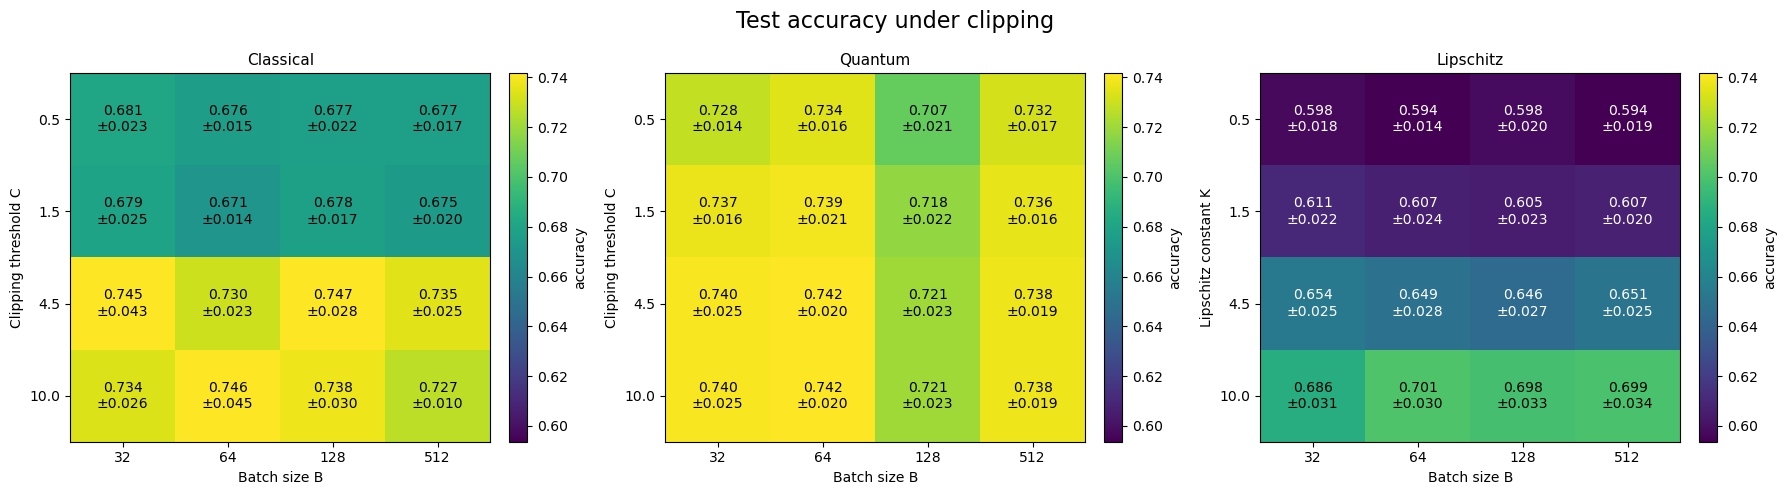

In [ ]:
plot_models = ("classical", "quantum", "lipschitz")
fig, axes = plt.subplots(1, len(plot_models), figsize=(len(plot_models) * 6, 5))
all_vals = np.concatenate([sweep_h1[mt].ravel() for mt in plot_models])
vmin, vmax = float(np.nanmin(all_vals)), float(np.nanmax(all_vals))
mid = (vmin + vmax) / 2

for ax, mt in zip(axes, plot_models):
    mat = sweep_h1[mt].copy()
    std = sweep_h1_std[mt]
    im = ax.imshow(mat, cmap="viridis", aspect="auto",
                   vmin=vmin, vmax=vmax, origin="upper")
    ax.set_xticks(range(len(batch_sizes_h1)))
    ax.set_xticklabels(batch_sizes_h1)
    ax.set_yticks(range(len(clip_thresholds_h1)))
    ax.set_yticklabels(clip_thresholds_h1)
    ax.set_xlabel("Batch size B")
    ax.set_ylabel("Lipschitz constant K" if mt == "lipschitz" else "Clipping threshold C")
    ax.set_title(mt.capitalize(), fontsize=11)
    for i in range(len(clip_thresholds_h1)):
        for j in range(len(batch_sizes_h1)):
            v = mat[i, j]
            s = std[i, j]
            txt = f"{v:.3f}\n±{s:.3f}" if not np.isnan(v) else "—"
            ax.text(j, i, txt, ha="center", va="center", fontsize=10,
                    color="white" if (np.isnan(v) or v < mid) else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="accuracy")

fig.suptitle("Test accuracy under clipping", fontsize=16)
plt.tight_layout(); plt.show()


In [ ]:
eps_list_h2        = [0.5, 1.0, 5.0, 10.0]
clip_thresholds_h2 = [0.5, 1.5, 4.5, 10.0]
B_h2               = 64
n_sweep_exp_h2     = 10
ref_epochs_h2      = 100

n_train_h2     = int(2048 * (1 - CFG.test_size))
sample_rate_h2 = B_h2 / n_train_h2
sigmas_h2 = {}
for eps in eps_list_h2:
    try:
        sigmas_h2[eps] = get_noise_multiplier(
            target_epsilon=eps, target_delta=CFG.delta,
            sample_rate=sample_rate_h2, epochs=ref_epochs_h2)
        print(f"ε={eps}:  σ={sigmas_h2[eps]:.3f}")
    except Exception as e:
        sigmas_h2[eps] = None
        print(f"ε={eps}:  INFEASIBLE  ({e})")


def _sweep_one_cell_h2(model_type, eps, C, B, n_exp, n_epochs, sigma):
    out = []
    for exp in range(n_exp):
        set_seed(CFG.seed + exp)
        label = f"{model_type}_tf_privacy"
        splits = build_dataset(CFG, label)
        loaders = []
        for i, (Xs, ys) in enumerate(splits):
            loaders.append(make_data_loader(
                torch.from_numpy(Xs), torch.from_numpy(ys),
                batch_size=B, shuffle=(i == 0)))
        train_loader, val_loader, _ = loaders

        if model_type == "lipschitz":
            model = LipschitzNet(CFG, K=C)
            lr = lr_for_lipschitz(C, B=B, sigma=sigma)
        elif model_type == "quantum":
            model = QuantumNet(CFG.n_features, CFG.quantum_encoding,
                               CFG.n_layers_pure, CFG.measure_qubits, CFG)
            lr = lr_with_cap(C, sigma, B, "quantum")
        else:
            model = ClassicalNet(cfg=CFG)
            lr = lr_with_cap(C, sigma, B, "classical")

        opt  = optim.SGD(model.parameters(), lr=lr,
                         momentum=CFG.momentum, weight_decay=CFG.weight_decay)
        crit = TauCrossEntropyLoss(tau=1.0)
        privacy_cfg = {
            "clipping":         "flat",
            "grad_sample_mode": "no_op" if model_type in ("quantum", "lipschitz") else "hooks",
            "max_grad_norm":    C,
            "target_epsilon":   eps,
            "target_delta":     CFG.delta,
        }
        _, _, _, va = train(
            model, opt, train_loader, val_loader, crit,
            n_epochs=n_epochs, quantum=(model_type == "quantum"),
            private=True, privacy_config=privacy_cfg, verbose=False,
        )
        out.append((float(max(va)), float(np.mean(va[-5:]))))
    return out


sweep_h2 = {}
sweep_h2_std = {}
for mt in ("classical", "lipschitz", "quantum"):
    print(f"\n{'='*60}\nMODEL: {mt}\n{'='*60}")
    sweep_h2[mt]     = np.full((len(eps_list_h2), len(clip_thresholds_h2)), np.nan)
    sweep_h2_std[mt] = np.full_like(sweep_h2[mt], np.nan)
    for ei, eps in enumerate(eps_list_h2):
        sigma = sigmas_h2[eps]
        if sigma is None:
            continue
        for ci, C in enumerate(clip_thresholds_h2):
            t0 = time.time()
            try:
                results_priv = _sweep_one_cell_h2(mt, eps, C, B_h2, n_sweep_exp_h2, ref_epochs_h2, sigma)
            except Exception as exc:
                print(f"  ε={eps}, C={C}:  ERROR {exc}")
                continue
            vmaxes = [r[0] for r in results_priv]
            sweep_h2[mt][ei, ci]     = float(np.mean(vmaxes))
            sweep_h2_std[mt][ei, ci] = float(np.std(vmaxes))
            print(f"  ε={eps}, C={C}:  val_max={np.mean(vmaxes):.3f} "
                  f"(±{np.std(vmaxes):.3f})   [{time.time()-t0:.1f}s]")

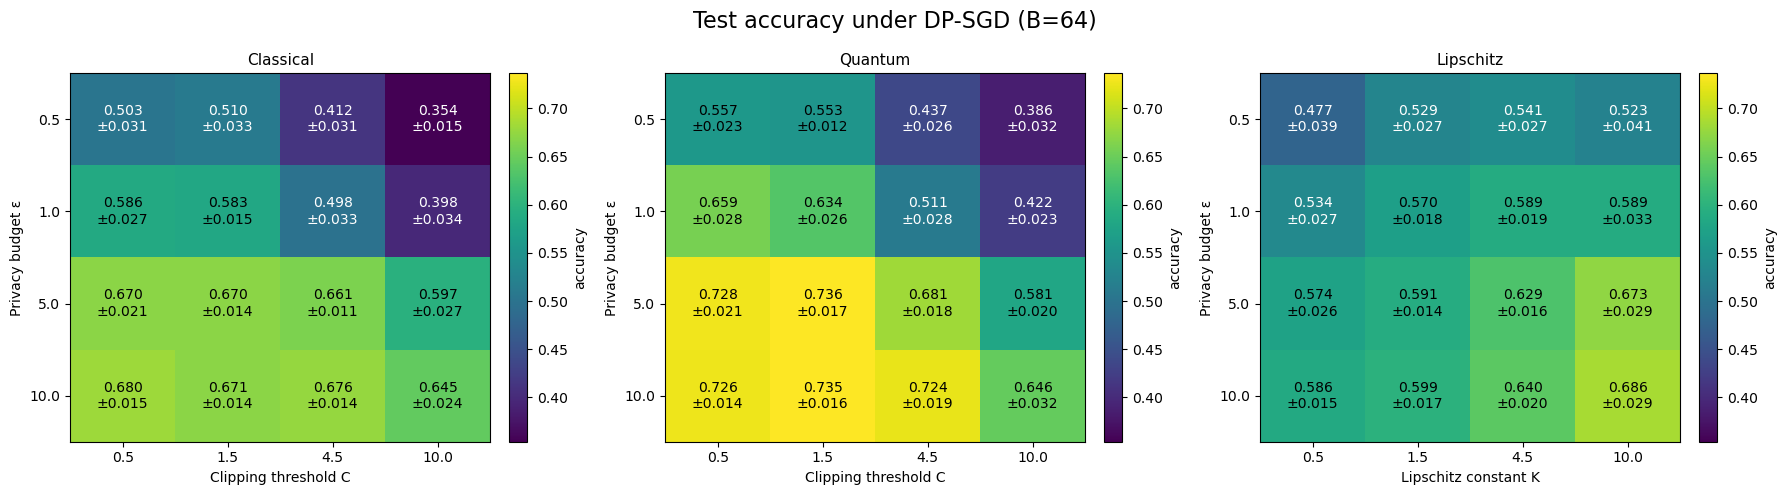

In [39]:
plot_models = ("classical", "quantum", "lipschitz")
fig, axes = plt.subplots(1, len(plot_models), figsize=(len(plot_models) * 6, 5))
valid_vals = np.concatenate([sweep_h2[mt].ravel() for mt in plot_models])
valid_vals = valid_vals[~np.isnan(valid_vals)]
vmin, vmax = float(np.min(valid_vals)), float(np.max(valid_vals))
mid = (vmin + vmax) / 2

for ax, mt in zip(axes, plot_models):
    mat = sweep_h2[mt]
    std = sweep_h2_std[mt]
    im = ax.imshow(mat, cmap="viridis", aspect="auto",
                   vmin=vmin, vmax=vmax, origin="upper")
    ax.set_xticks(range(len(clip_thresholds_h2)))
    ax.set_xticklabels(clip_thresholds_h2)
    ax.set_yticks(range(len(eps_list_h2)))
    ax.set_yticklabels(eps_list_h2)
    ax.set_xlabel("Lipschitz constant K" if mt == "lipschitz" else "Clipping threshold C")
    ax.set_ylabel("Privacy budget ε")
    ax.set_title(mt.capitalize(), fontsize=11)
    for i in range(len(eps_list_h2)):
        for j in range(len(clip_thresholds_h2)):
            v = mat[i, j]; s = std[i, j]
            txt = f"{v:.3f}\n±{s:.3f}" if not np.isnan(v) else "—"
            ax.text(j, i, txt, ha="center", va="center", fontsize=10,
                    color="white" if (np.isnan(v) or v < mid) else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="accuracy")

fig.suptitle("Test accuracy under DP-SGD (B=64)", fontsize=16)
plt.tight_layout(); plt.show()
